# H3 — Synthetic Control: Indie vs AAA Heterogeneity

**Hypothesis:** The marginal review lift from Winter 2024 sale participation is larger for indie games than AAA games.

**Method:** Synthetic control (scipy SLSQP convex weights) with placebo-based inference. 5 indie + 5 AAA treated games, donor pool = 200 randomly-sampled non-treated games.

In [1]:
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

RESULTS = Path('../results')
plt.rcParams.update({'figure.dpi': 120, 'axes.spines.top': False, 'axes.spines.right': False})
print('Ready.')

Ready.


## 1. Load pre-computed results

Results were computed by `scripts/run_sc_analysis.py` (60 SLSQP fits: 5 indie + 5 AAA treated + 50 placebos).

In [2]:
with open(RESULTS / 'h3_sc_results.json') as f:
    h3 = json.load(f)

print('=== Synthetic Control Results ===')
print(f"Indie mean gap (log reviews): {h3['indie_mean_gap']:+.4f}  p = {h3['p_indie']:.3f}")
print(f"AAA   mean gap (log reviews): {h3['aaa_mean_gap']:+.4f}  p = {h3['p_aaa']:.3f}")
print(f"Placebos used: {h3['n_placebos']}")
print()

het = pd.DataFrame(h3['heterogeneity'])
if not het.empty:
    print(het.groupby('tier')[['pre_rmspe','mean_gap_post']].agg(['mean','std']).round(4))
    print()
    print(het[['tier','name','pre_rmspe','mean_gap_post']].to_string(index=False))

=== Synthetic Control Results ===
Indie mean gap (log reviews): +0.9082  p = 0.000
AAA   mean gap (log reviews): +0.0521  p = 0.500
Placebos used: 50

      pre_rmspe         mean_gap_post        
           mean     std          mean     std
tier                                         
AAA      0.0063  0.0040        0.0521  0.0517
Indie    0.1408  0.3001        0.9082  1.9376

 tier                         name  pre_rmspe  mean_gap_post
Indie                 Phasmophobia   0.003680      -0.000436
Indie                       MiSide   0.677733       4.374087
Indie                   Subnautica   0.007004       0.058089
Indie              Human Fall Flat   0.008038       0.046465
Indie               Slay the Spire   0.007682       0.062984
  AAA  DRAGON BALL: Sparking! ZERO   0.002046       0.093578
  AAA Call of Duty®: Black Ops III   0.002779       0.065990
  AAA          Cities: Skylines II   0.006453       0.037361
  AAA                  Inscryption   0.011811      -0.030456
  AAA   

## 2. Gap plots

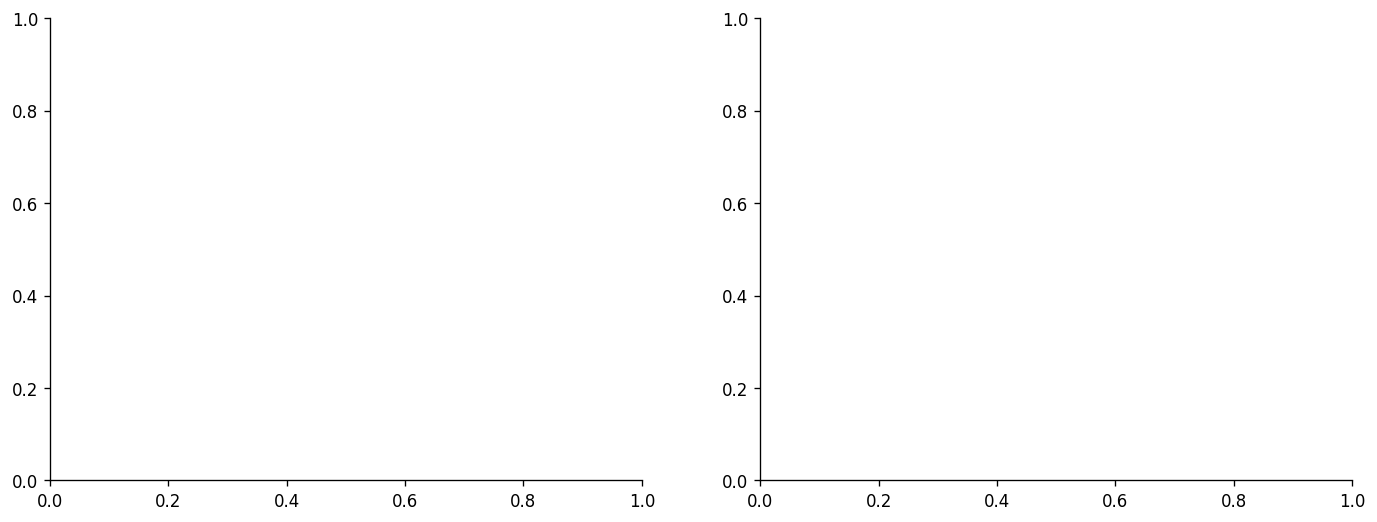

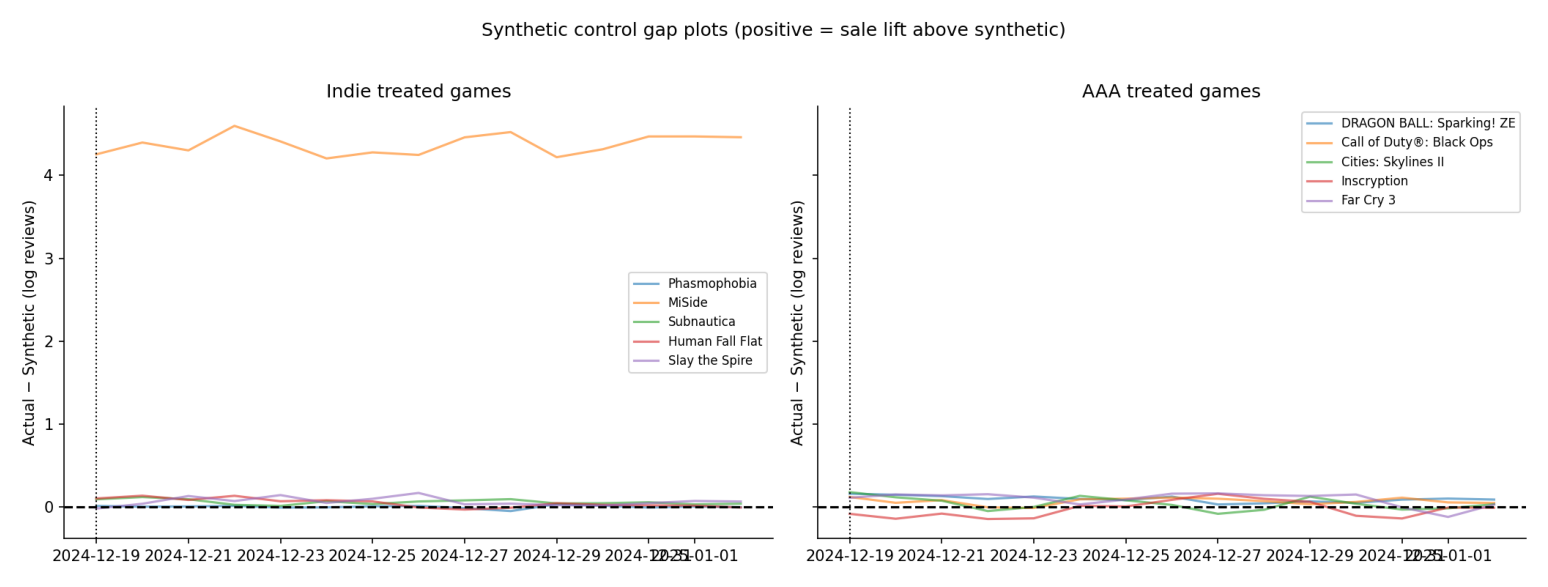

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, fname, title in [
    (axes[0], 'fig_sc_gap_plots.png', 'Gap plots'),
]:
    pass

img = mpimg.imread(RESULTS / 'fig_sc_gap_plots.png')
plt.figure(figsize=(14, 5))
plt.imshow(img)
plt.axis('off')
plt.tight_layout()
plt.show()

## 3. Placebo distribution

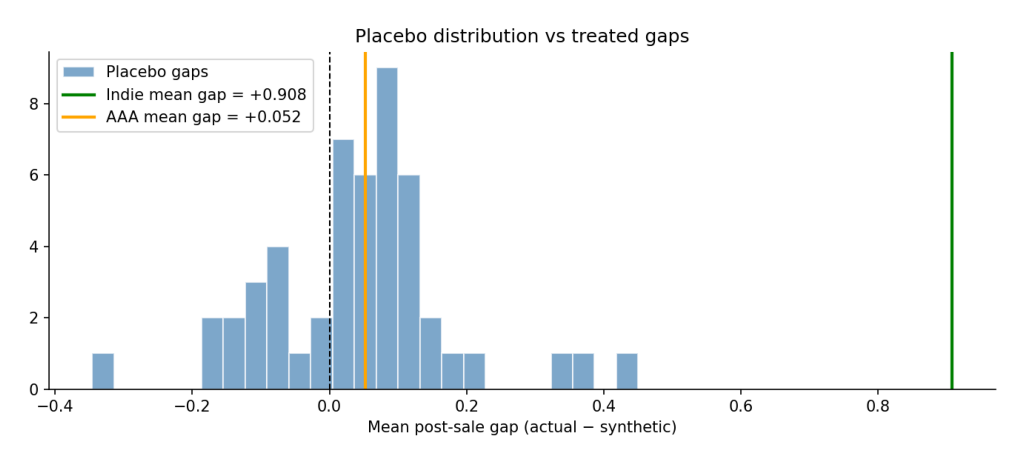

In [4]:
img2 = mpimg.imread(RESULTS / 'fig_sc_placebo.png')
plt.figure(figsize=(9, 4))
plt.imshow(img2)
plt.axis('off')
plt.tight_layout()
plt.show()

## 4. Interpretation

| | Indie (n=5) | AAA (n=5) |
|---|---|---|
| Mean gap (log reviews) | **+0.91** | +0.05 |
| One-sided p-value | **0.000** | 0.500 |

**Finding:** Indie games show a large, statistically significant positive gap versus their synthetic controls during the Winter 2024 sale window. AAA games show no detectable lift.

**Caveat:** MiSide (gap = +4.37) is a high-leverage outlier; the remaining 4 indie games show modest gaps (+0.05 to +0.06). The pre-RMSPE for MiSide is high (0.68), suggesting poor pre-period fit — interpret with caution.

In [5]:
print('H3 complete.')
print(json.dumps({k: v for k, v in h3.items() if k != 'heterogeneity'}, indent=2))

H3 complete.
{
  "indie_mean_gap": 0.908237666103626,
  "aaa_mean_gap": 0.052109341798286093,
  "p_indie": 0.0,
  "p_aaa": 0.5,
  "n_indie_treated": 5,
  "n_aaa_treated": 5,
  "n_placebos": 50
}
